# Revision ML Baselines, Ablations, and BEP Dependence

Objective: add a reviewer-runnable analysis for the key ML criticism: whether the descriptor model merely learns the BEP relation from `DeltaG_rxn`, or whether non-BEP descriptors add predictive information.

Primary inputs:
- `Data/TS/Borane_all.csv`: final 9237 IRC-validated transition-state dataset.
- `Data/descriptor/BNdes_new2.pkl` and `Data/descriptor/Cldes_new2.pkl`: pre-extracted descriptor maps used by `5_Modeling.ipynb`.
- Optional: `catboost` or `xgboost` if installed. The notebook remains runnable with scikit-learn only.

Outputs:
- `Data/csvs/model_baseline_random_cv.csv`
- `Data/csvs/model_baseline_ood.csv`
- `Data/csvs/model_ablation_summary.csv`
- `Data/csvs/model_bep_dependence_summary.csv`
- `Figure/FigureS_model_baselines.png`
- `Figure/FigureS_model_ablation.png`
- `Figure/FigureS_bep_dependence.png`

## Plan

1. Load the released descriptor pickle files without regenerating descriptors from Gaussian/ASE data.
2. Reproduce the BEP baseline (`DeltaG_rxn` only) and compare it with simple ML baselines.
3. Run ablations that remove or isolate `DeltaG_rxn`, component blocks, electronic descriptors, and geometric/steric descriptors.
4. Add OOD checks by Lewis-base type and chloride-substrate type; B-type OOD is included automatically when RDKit is available.
5. Quantify BEP dependence in two ways: full model vs `DeltaG_rxn`-free model, and a BEP-residual model that learns only the residual left after linear BEP.

In [5]:
from __future__ import annotations

from pathlib import Path
import math
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

RANDOM_STATE = 0
N_SPLITS = 5
FAST_MODE = False
HARTREE_TO_KCAL = 627.5

TS_CSV = Path('Data/TS/Borane_all.csv')
BN_DESCRIPTOR_PKL = Path('Data/descriptor/BNdes_new2.pkl')
CL_DESCRIPTOR_PKL = Path('Data/descriptor/Cldes_new2.pkl')
CSV_DIR = Path('Data/csvs')
FIGURE_DIR = Path('Figure')
CSV_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RF_TREES = 160 if FAST_MODE else 500
ET_TREES = 180 if FAST_MODE else 600
HGB_ITER = 220 if FAST_MODE else 600
PERMUTATION_ROWS = 1800 if FAST_MODE else 5000

plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.size': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('FAST_MODE:', FAST_MODE)
print('Input CSV:', TS_CSV.resolve())

FAST_MODE: False
Input CSV: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Data\TS\Borane_all.csv


In [6]:
DUPLICATE_CL_IDS = {
    624, 625, 626, 627, 628, 629, 630, 631, 632, 633, 634, 635, 636,
    637, 638, 639, 640, 642, 644, 645, 652, 653, 654, 655, 656, 657,
    658, 659, 660, 661, 662, 663, 664, 665, 666, 667, 668, 669, 670,
    671, 672, 673, 674, 675, 676, 677, 678, 679, 680, 681, 682, 683,
    684, 685, 686, 687, 688, 689, 690, 691, 692, 693, 694, 695, 696,
    697, 698, 699, 700, 701, 702, 703, 704, 705, 706, 707, 708, 709,
    710, 711, 713, 714, 716, 717, 718, 719, 720, 721, 722,
}

FEATURE_NAMES = [
    'DeltaG_rxn',
    'LB-B spin_B', 'LB-B qH_B', 'LB-B distance', 'LB-B HOMO/SOMO',
    'LB-B-Cl qH_B', 'LB-B-Cl qH_Cl', 'LB-B-Cl B-Cl distance',
    'LB-B-Cl LUMO', 'LB-B-Cl buried_volume_B',
    'C-Cl qH_Cl', 'C-Cl qH_C', 'C-Cl distance', 'C-Cl LUMO',
    'C-Cl buried_volume_C', 'C radical spin_C', 'C radical qH_C',
    'C radical HOMO/SOMO',
]

FEATURE_GROUPS = {
    'full_18_descriptors': list(range(18)),
    'DeltaG_rxn_only': [0],
    'all_except_DeltaG_rxn': list(range(1, 18)),
    'LB_B_reactant_only': [1, 2, 3, 4],
    'LB_B_Cl_product_only': [5, 6, 7, 8, 9],
    'C_Cl_reactant_only': [10, 11, 12, 13, 14],
    'C_radical_only': [15, 16, 17],
    'electronic_with_DeltaG_rxn': [0, 1, 2, 4, 5, 6, 8, 10, 11, 13, 15, 16, 17],
    'electronic_without_DeltaG_rxn': [1, 2, 4, 5, 6, 8, 10, 11, 13, 15, 16, 17],
    'geometric_steric_only': [3, 7, 9, 12, 14],
    'no_DeltaG_no_bond_distances': [1, 2, 4, 5, 6, 8, 9, 10, 11, 13, 14, 15, 16, 17],
}


def load_pickle(path):
    with path.open('rb') as handle:
        return pickle.load(handle)


def descriptor_matrix(df, bn_map, cl_map):
    rows = []
    missing = []
    for idx, row in df.iterrows():
        b_index = int(row['B_Index'])
        n_index = int(row['N_Index'])
        cl_index = int(row['Cl_Index'])
        cl_atomid = int(row['Cl_Atomid'])
        bn_key = f'B_{b_index:05d}_Nu_{n_index:05d}'
        cl_key = f'Cl_{cl_index:05d}_Claid_{cl_atomid:05d}' if cl_index in DUPLICATE_CL_IDS else f'Cl_{cl_index:05d}'
        if bn_key not in bn_map or cl_key not in cl_map:
            missing.append((idx, bn_key, cl_key))
            continue
        des_a = bn_map[bn_key]
        des_b = cl_map[cl_key]
        delta_g = [(des_a[0] + des_b[0]) * HARTREE_TO_KCAL]
        rows.append(delta_g + des_a[1:] + des_b[1:])
    if missing:
        raise KeyError(f'Missing descriptors for {len(missing)} rows; first examples: {missing[:5]}')
    return np.asarray(rows, dtype=float)

bn_map = load_pickle(BN_DESCRIPTOR_PKL)
cl_map = load_pickle(CL_DESCRIPTOR_PKL)
rxn_df = pd.read_csv(TS_CSV)
X = descriptor_matrix(rxn_df, bn_map, cl_map)
y = rxn_df['deltaGa(kcal/mol)'].to_numpy(dtype=float)
feature_df = pd.DataFrame(X, columns=FEATURE_NAMES)

summary = {
    'n_reactions': len(rxn_df),
    'n_features': X.shape[1],
    'deltaG_csv_vs_descriptor_max_abs': float(np.max(np.abs(feature_df['DeltaG_rxn'].to_numpy() - rxn_df['deltaG(kcal/mol)'].to_numpy()))),
}
print(summary)
display(feature_df.describe().T[['mean', 'std', 'min', 'max']])

{'n_reactions': 9237, 'n_features': 18, 'deltaG_csv_vs_descriptor_max_abs': 0.0011922500250527435}


,mean,std,min,max
DeltaG_rxn,-20.132205,10.008263,-63.428139,-4.102344
LB-B spin_B,0.389623,0.280863,-0.094798,1.232969
LB-B qH_B,0.053811,0.100833,-0.213611,0.367634
LB-B distance,1.564299,0.164043,1.403717,1.998987
LB-B HOMO/SOMO,-147.205881,20.303509,-205.067000,-90.127825
LB-B-Cl qH_B,0.030436,0.053342,-0.121349,0.213188
LB-B-Cl qH_Cl,-0.228299,0.038735,-0.443678,-0.084846
LB-B-Cl B-Cl distance,1.898972,0.033561,1.809246,2.187198
LB-B-Cl LUMO,-7.557023,25.571839,-81.455775,37.982575
LB-B-Cl buried_volume_B,208.038271,47.078281,74.822441,435.634269


## Type Columns For OOD Splits

Lewis-base classes are deterministic from `N_Index`. Chloride-substrate and boron-radical classes use RDKit when available. Without RDKit, chloride classes fall back to a conservative SMILES heuristic and B-type OOD is skipped rather than silently misclassified.

In [7]:
LB_TYPE_ORDER = ['Amine/Aryl N', 'Phosphine', 'NHC']
CL_TYPE_ORDER = ['CCl4', 'CCl3', 'CCl2', 'CCl']
B_TYPE_ORDER = ['BR3', 'R2BH', 'RBH2', 'BH3']


def get_lb_type(lb_id):
    lb_id = int(lb_id)
    if 0 <= lb_id < 69 or 234 <= lb_id < 388:
        return 'Amine/Aryl N'
    if 69 <= lb_id < 144:
        return 'Phosphine'
    if 144 <= lb_id < 234:
        return 'NHC'
    return 'Other'

try:
    from rdkit import Chem
    HAS_RDKIT = True
except Exception:
    Chem = None
    HAS_RDKIT = False


def get_cl_type(smiles):
    if HAS_RDKIT:
        mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
        patterns = [
            ('CCl4', Chem.MolFromSmarts('Cl*(Cl)(Cl)Cl')),
            ('CCl3', Chem.MolFromSmarts('Cl*(Cl)Cl')),
            ('CCl2', Chem.MolFromSmarts('Cl*Cl')),
        ]
        for label, patt in patterns:
            if mol is not None and mol.HasSubstructMatch(patt):
                return label
        return 'CCl'
    text = str(smiles)
    if '(Cl)(Cl)(Cl)Cl' in text:
        return 'CCl4'
    if '(Cl)(Cl)Cl' in text:
        return 'CCl3'
    if '(Cl)Cl' in text or 'C(Cl)Cl' in text:
        return 'CCl2'
    return 'CCl'


def get_b_type(smiles):
    if not HAS_RDKIT:
        return np.nan
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.nan
    b_atoms = [atom for atom in mol.GetAtoms() if atom.GetSymbol() == 'B']
    if not b_atoms:
        return np.nan
    n_h = b_atoms[0].GetTotalNumHs()
    return {0: 'BR3', 1: 'R2BH', 2: 'RBH2', 3: 'BH3'}.get(n_h, f'BH{n_h}')

typed_df = rxn_df.copy()
typed_df['LB_type'] = typed_df['N_Index'].map(get_lb_type)
typed_df['Cl_type'] = typed_df['Cl_smiles'].map(get_cl_type)
typed_df['B_type'] = typed_df['B_smiles'].map(get_b_type)

print('RDKit available:', HAS_RDKIT)
for col, order in [('LB_type', LB_TYPE_ORDER), ('Cl_type', CL_TYPE_ORDER), ('B_type', B_TYPE_ORDER)]:
    counts = typed_df[col].value_counts(dropna=False).reindex(order if col != 'B_type' else order).dropna()
    print('\n' + col)
    print(counts.to_string())

RDKit available: True

LB_type
LB_type
Amine/Aryl N    5897
Phosphine       1833
NHC             1507

Cl_type
Cl_type
CCl4     212
CCl3    1793
CCl2    2107
CCl     5125

B_type
B_type
R2BH    2500.0
RBH2    5934.0
BH3      803.0


## Evaluation Helpers

All metrics below use out-of-fold predictions for random CV. OOD metrics train on all rows except the held-out component type and test on that held-out type.

In [8]:
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5


def metric_row(label, split, model_name, feature_set, y_true, y_pred, extra=None):
    row = {
        'label': label,
        'split': split,
        'model': model_name,
        'feature_set': feature_set,
        'n': int(len(y_true)),
        'R2': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': rmse(y_true, y_pred),
    }
    if extra:
        row.update(extra)
    return row


def subset_X(X_full, feature_ids):
    return X_full[:, feature_ids]


def make_baseline_models():
    models = {
        'mean': lambda: DummyRegressor(strategy='mean'),
        'BEP_linear_DeltaG': lambda: LinearRegression(),
        'ridge_all': lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-4, 4, 17))),
        'elastic_net_all': lambda: make_pipeline(StandardScaler(), ElasticNet(alpha=0.001, l1_ratio=0.15, max_iter=20000, random_state=RANDOM_STATE)),
        'kNN_all': lambda: make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=15, weights='distance')),
        'random_forest_all': lambda: RandomForestRegressor(n_estimators=RF_TREES, min_samples_leaf=1, random_state=RANDOM_STATE, n_jobs=-1),
        'extra_trees_all': lambda: ExtraTreesRegressor(n_estimators=ET_TREES, min_samples_leaf=1, random_state=RANDOM_STATE, n_jobs=-1),
        'hist_gradient_boosting_all': lambda: HistGradientBoostingRegressor(max_iter=HGB_ITER, learning_rate=0.05, l2_regularization=0.02, random_state=RANDOM_STATE),
    }
    try:
        from catboost import CatBoostRegressor
        cat_iter = 1200 if FAST_MODE else 10000
        models['catboost_all'] = lambda: CatBoostRegressor(iterations=cat_iter, learning_rate=0.03 if FAST_MODE else 0.01, depth=6, verbose=0, random_state=RANDOM_STATE)
    except Exception as exc:
        print('CatBoost unavailable; skipped:', exc)
    try:
        from xgboost import XGBRegressor
        xgb_trees = 300 if FAST_MODE else 900
        models['xgboost_all'] = lambda: XGBRegressor(n_estimators=xgb_trees, max_depth=4, learning_rate=0.04, subsample=0.9, colsample_bytree=0.9, objective='reg:squarederror', random_state=RANDOM_STATE, n_jobs=-1)
    except Exception as exc:
        print('XGBoost unavailable; skipped:', exc)
    return models


def model_feature_set(model_name):
    if model_name == 'mean':
        return []
    if model_name == 'BEP_linear_DeltaG':
        return FEATURE_GROUPS['DeltaG_rxn_only']
    return FEATURE_GROUPS['full_18_descriptors']


def evaluate_cv(model_factory, model_name, feature_set_name, feature_ids, X_full, y_values, n_splits=N_SPLITS):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros_like(y_values, dtype=float)
    fold_rows = []
    X_use = np.zeros((len(y_values), 1)) if not feature_ids else subset_X(X_full, feature_ids)
    for fold, (train_idx, test_idx) in enumerate(kf.split(X_use), start=1):
        model = model_factory()
        model.fit(X_use[train_idx], y_values[train_idx])
        pred = model.predict(X_use[test_idx])
        oof[test_idx] = pred
        fold_rows.append(metric_row('fold', f'fold_{fold}', model_name, feature_set_name, y_values[test_idx], pred, {'fold': fold}))
    overall = metric_row('overall', 'random_5fold_oof', model_name, feature_set_name, y_values, oof)
    return overall, pd.DataFrame(fold_rows), oof


def evaluate_type_ood(model_factory, model_name, feature_set_name, feature_ids, X_full, y_values, meta_df, type_column, type_order):
    rows = []
    preds = []
    X_use = np.zeros((len(y_values), 1)) if not feature_ids else subset_X(X_full, feature_ids)
    for heldout in type_order:
        test_mask = meta_df[type_column].eq(heldout).to_numpy()
        if test_mask.sum() < 2 or (~test_mask).sum() < 2:
            continue
        model = model_factory()
        model.fit(X_use[~test_mask], y_values[~test_mask])
        pred = model.predict(X_use[test_mask])
        rows.append(metric_row(
            'heldout_type', f'leave_one_{type_column}', model_name, feature_set_name,
            y_values[test_mask], pred,
            {'OOD_axis': type_column, 'heldout_type': heldout, 'train_size': int((~test_mask).sum()), 'test_size': int(test_mask.sum())},
        ))
        preds.append(pd.DataFrame({
            'model': model_name,
            'feature_set': feature_set_name,
            'OOD_axis': type_column,
            'heldout_type': heldout,
            'y_true': y_values[test_mask],
            'y_pred': pred,
        }))
    return pd.DataFrame(rows), pd.concat(preds, ignore_index=True) if preds else pd.DataFrame()

## Baseline Models: Random 5-Fold CV

This table starts from deliberately weak baselines. The key comparison is `BEP_linear_DeltaG` vs nonlinear full-descriptor models and, later, `all_except_DeltaG_rxn` ablations.

In [5]:
baseline_models = make_baseline_models()
baseline_rows = []
baseline_fold_rows = []
baseline_predictions = {}

for model_name, factory in baseline_models.items():
    ids = model_feature_set(model_name)
    feature_set_name = 'none' if model_name == 'mean' else ('DeltaG_rxn_only' if model_name == 'BEP_linear_DeltaG' else 'full_18_descriptors')
    print(f'Running CV: {model_name} ({feature_set_name})')
    overall, folds, oof = evaluate_cv(factory, model_name, feature_set_name, ids, X, y)
    baseline_rows.append(overall)
    baseline_fold_rows.append(folds)
    baseline_predictions[model_name] = oof

baseline_cv = pd.DataFrame(baseline_rows).sort_values('MAE').reset_index(drop=True)
baseline_folds = pd.concat(baseline_fold_rows, ignore_index=True)
baseline_cv.to_csv(CSV_DIR / 'model_baseline_random_cv.csv', index=False)
baseline_folds.to_csv(CSV_DIR / 'model_baseline_random_cv_folds.csv', index=False)
display(baseline_cv)

Running CV: mean (none)
Running CV: BEP_linear_DeltaG (DeltaG_rxn_only)
Running CV: ridge_all (full_18_descriptors)
Running CV: elastic_net_all (full_18_descriptors)
Running CV: kNN_all (full_18_descriptors)
Running CV: random_forest_all (full_18_descriptors)
Running CV: extra_trees_all (full_18_descriptors)
Running CV: hist_gradient_boosting_all (full_18_descriptors)
Running CV: catboost_all (full_18_descriptors)
Running CV: xgboost_all (full_18_descriptors)


,label,split,model,feature_set,n,R2,MAE,RMSE
0,overall,random_5fold_oof,catboost_all,full_18_descriptors,9237,0.906096,1.391403,1.944484
1,overall,random_5fold_oof,xgboost_all,full_18_descriptors,9237,0.893794,1.493230,2.067938
2,overall,random_5fold_oof,hist_gradient_boosting_all,full_18_descriptors,9237,0.891307,1.494461,2.092011
3,overall,random_5fold_oof,extra_trees_all,full_18_descriptors,9237,0.872058,1.646458,2.269704
4,overall,random_5fold_oof,random_forest_all,full_18_descriptors,9237,0.852136,1.749054,2.440018
5,overall,random_5fold_oof,kNN_all,full_18_descriptors,9237,0.789518,2.137506,2.911181
6,overall,random_5fold_oof,ridge_all,full_18_descriptors,9237,0.641360,2.780987,3.800069
7,overall,random_5fold_oof,elastic_net_all,full_18_descriptors,9237,0.641355,2.781227,3.800097
8,overall,random_5fold_oof,BEP_linear_DeltaG,DeltaG_rxn_only,9237,0.525164,3.251748,4.372542
9,overall,random_5fold_oof,mean,none,9237,-0.000128,5.201431,6.345852


## Baseline Models: Type-OOD Checks

Run OOD checks for the most interpretable baseline (`BEP_linear_DeltaG`) and the best available nonlinear full-descriptor models. These splits are closer to the reviewer's requested leave-class-out validation than random CV.

In [6]:
ood_model_names = [name for name in [
    'BEP_linear_DeltaG',
    'hist_gradient_boosting_all',
    'random_forest_all',
    'catboost_all',
] if name in baseline_models]

ood_axes = [('LB_type', LB_TYPE_ORDER), ('Cl_type', CL_TYPE_ORDER)]
if typed_df['B_type'].notna().sum() > 0:
    ood_axes.append(('B_type', B_TYPE_ORDER))
else:
    print('B_type OOD skipped because RDKit is unavailable for B-type assignment in this environment.')

ood_rows = []
ood_pred_frames = []
for model_name in ood_model_names:
    ids = model_feature_set(model_name)
    feature_set_name = 'DeltaG_rxn_only' if model_name == 'BEP_linear_DeltaG' else 'full_18_descriptors'
    for axis, order in ood_axes:
        print(f'Running OOD: {model_name}, {axis}')
        rows, pred_df = evaluate_type_ood(baseline_models[model_name], model_name, feature_set_name, ids, X, y, typed_df, axis, order)
        if not rows.empty:
            ood_rows.append(rows)
        if not pred_df.empty:
            ood_pred_frames.append(pred_df)

baseline_ood = pd.concat(ood_rows, ignore_index=True) if ood_rows else pd.DataFrame()
baseline_ood_predictions = pd.concat(ood_pred_frames, ignore_index=True) if ood_pred_frames else pd.DataFrame()
baseline_ood.to_csv(CSV_DIR / 'model_baseline_ood.csv', index=False)
baseline_ood_predictions.to_csv(CSV_DIR / 'model_baseline_ood_predictions.csv', index=False)
display(baseline_ood.sort_values(['OOD_axis', 'heldout_type', 'MAE']) if not baseline_ood.empty else baseline_ood)

Running OOD: BEP_linear_DeltaG, LB_type
Running OOD: BEP_linear_DeltaG, Cl_type
Running OOD: BEP_linear_DeltaG, B_type
Running OOD: hist_gradient_boosting_all, LB_type
Running OOD: hist_gradient_boosting_all, Cl_type
Running OOD: hist_gradient_boosting_all, B_type
Running OOD: random_forest_all, LB_type
Running OOD: random_forest_all, Cl_type
Running OOD: random_forest_all, B_type
Running OOD: catboost_all, LB_type
Running OOD: catboost_all, Cl_type
Running OOD: catboost_all, B_type


,label,split,model,feature_set,n,R2,MAE,RMSE,OOD_axis,heldout_type,train_size,test_size
39,heldout_type,leave_one_B_type,catboost_all,full_18_descriptors,803,0.936600,1.120740,1.538690,B_type,BH3,8434,803
29,heldout_type,leave_one_B_type,random_forest_all,full_18_descriptors,803,0.910391,1.330254,1.829285,B_type,BH3,8434,803
19,heldout_type,leave_one_B_type,hist_gradient_boosting_all,full_18_descriptors,803,0.918583,1.337115,1.743667,B_type,BH3,8434,803
9,heldout_type,leave_one_B_type,BEP_linear_DeltaG,DeltaG_rxn_only,803,0.716035,2.372216,3.256403,B_type,BH3,8434,803
37,heldout_type,leave_one_B_type,catboost_all,full_18_descriptors,2500,0.808557,2.041933,2.849475,B_type,R2BH,6737,2500
17,heldout_type,leave_one_B_type,hist_gradient_boosting_all,full_18_descriptors,2500,0.787896,2.161350,2.999300,B_type,R2BH,6737,2500
27,heldout_type,leave_one_B_type,random_forest_all,full_18_descriptors,2500,0.720031,2.501812,3.445881,B_type,R2BH,6737,2500
7,heldout_type,leave_one_B_type,BEP_linear_DeltaG,DeltaG_rxn_only,2500,0.451243,3.561844,4.824307,B_type,R2BH,6737,2500
38,heldout_type,leave_one_B_type,catboost_all,full_18_descriptors,5934,0.854490,1.755245,2.369579,B_type,RBH2,3303,5934
18,heldout_type,leave_one_B_type,hist_gradient_boosting_all,full_18_descriptors,5934,0.831376,1.892282,2.550852,B_type,RBH2,3303,5934


In [9]:
# ## Scaffold-Disjoint and Leave-One-Substituent-Family-Out Validation
# Reviewer-facing OOD cell. It is intentionally self-contained and uses only three
# model settings: BEP, CatBoost full descriptors, and CatBoost without DeltaG_rxn.
# If CatBoost is unavailable, it falls back to HistGradientBoosting.

from sklearn.model_selection import GroupKFold

try:
    from rdkit import Chem
    from rdkit.Chem.Scaffolds import MurckoScaffold
    HAS_RDKIT_SCAFFOLD = True
except Exception as exc:
    HAS_RDKIT_SCAFFOLD = False
    print('RDKit unavailable; scaffold/family OOD skipped:', exc)

RUN_SCAFFOLD_FAMILY_OOD = True
SCAFFOLD_N_SPLITS = 5
MIN_FAMILY_TEST_SIZE = 80
SCAFFOLD_CATBOOST_ITERATIONS = 300 if FAST_MODE else 1200


def make_review_catboost_or_hgb(seed=RANDOM_STATE):
    try:
        from catboost import CatBoostRegressor
        return CatBoostRegressor(
            iterations=SCAFFOLD_CATBOOST_ITERATIONS,
            learning_rate=0.04 if FAST_MODE else 0.02,
            depth=6,
            verbose=0,
            random_state=seed,
        )
    except Exception:
        return HistGradientBoostingRegressor(
            max_iter=HGB_ITER,
            learning_rate=0.05,
            l2_regularization=0.02,
            random_state=seed,
        )


def canonical_smiles(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return f'invalid:{smiles}'
    return Chem.MolToSmiles(mol, isomericSmiles=False)


def murcko_or_acyclic_fallback(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return f'invalid:{smiles}'
    scaffold_mol = MurckoScaffold.GetScaffoldForMol(mol)
    scaffold = Chem.MolToSmiles(scaffold_mol, isomericSmiles=False)
    if scaffold:
        return scaffold
    # Acyclic molecules have empty Murcko scaffolds; use canonical acyclic skeleton
    # as a conservative fallback to keep exact acyclic structures group-disjoint.
    return 'acyclic:' + Chem.MolToSmiles(mol, isomericSmiles=False)


def has_substructure(mol, smarts):
    patt = Chem.MolFromSmarts(smarts)
    return bool(patt is not None and mol is not None and mol.HasSubstructMatch(patt))


def classify_lb_family(smiles, n_index):
    mol = Chem.MolFromSmiles(str(smiles))
    lb_type = get_lb_type(n_index)
    if lb_type == 'NHC':
        return 'NHC'
    if lb_type == 'Phosphine':
        if mol is not None:
            p_atoms = [a for a in mol.GetAtoms() if a.GetSymbol() == 'P']
            if any(any(nbr.GetIsAromatic() for nbr in atom.GetNeighbors()) for atom in p_atoms):
                return 'aryl_phosphine'
        return 'alkyl_phosphine'
    if mol is not None and any(a.GetSymbol() == 'N' and a.GetIsAromatic() for a in mol.GetAtoms()):
        return 'aryl_N_base'
    if has_substructure(mol, '[NX3]([#6])([#6])[#6]'):
        return 'tertiary_amine'
    if has_substructure(mol, '[NX3H]'):
        return 'secondary_or_primary_amine'
    return 'other_amine_N_base'


def classify_b_family(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    text = str(smiles)
    if mol is None:
        return 'invalid_B'
    if text == 'B':
        return 'BH3'
    b_atoms = [a for a in mol.GetAtoms() if a.GetSymbol() == 'B']
    b_atom = b_atoms[0] if b_atoms else None
    b_neighbors = [nbr.GetSymbol() for nbr in b_atom.GetNeighbors()] if b_atom is not None else []
    if 'F' in b_neighbors or 'Cl' in b_neighbors:
        return 'haloborane'
    if 'N' in b_neighbors:
        return 'aminoborane'
    if 'O' in b_neighbors:
        return 'alkoxy_acyloxy_borane'
    if 'S' in b_neighbors or 'Si' in b_neighbors:
        return 'thio_silyl_borane'
    if has_substructure(mol, '[B]-[C]#N'):
        return 'cyanoborane'
    if any(nbr.GetIsAromatic() for nbr in b_atom.GetNeighbors()) if b_atom is not None else False:
        return 'aryl_borane'
    if mol.GetRingInfo().NumRings() > 0:
        return 'cyclic_alkyl_borane'
    return 'alkyl_borane'


def classify_cl_family(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return 'invalid_Cl'
    if has_substructure(mol, '[C;X4](Cl)(Cl)(Cl)Cl'):
        return 'CCl4_family'
    if has_substructure(mol, '[C;X4](Cl)(Cl)Cl'):
        return 'trichloromethyl'
    if has_substructure(mol, '[C;X4](Cl)Cl'):
        return 'dichloromethyl'
    if has_substructure(mol, '[c][Cl]'):
        return 'aryl_chloride'
    if has_substructure(mol, '[C,c]=[C,c][Cl]'):
        return 'vinylic_allylic_chloride'
    if has_substructure(mol, '[C,S](=O)-[C;X4][Cl]'):
        return 'alpha_carbonyl_sulfonyl_chloride'
    if has_substructure(mol, '[N,O,S]-[C;X4][Cl]'):
        return 'heteroatom_adjacent_alkyl_chloride'
    return 'alkyl_chloride'


def evaluate_groupkfold_ood(model_name, model_factory, feature_set_name, feature_ids, group_column, meta_df):
    groups = meta_df[group_column].astype(str).to_numpy()
    unique_groups = np.unique(groups)
    n_splits = min(SCAFFOLD_N_SPLITS, len(unique_groups))
    if n_splits < 2:
        return pd.DataFrame()
    X_use = subset_X(X, feature_ids)
    pred = np.zeros_like(y, dtype=float)
    rows = []
    gkf = GroupKFold(n_splits=n_splits)
    for fold, (train_idx, test_idx) in enumerate(gkf.split(X_use, y, groups), start=1):
        model = model_factory()
        model.fit(X_use[train_idx], y[train_idx])
        y_pred = model.predict(X_use[test_idx])
        pred[test_idx] = y_pred
        rows.append(metric_row(
            'fold', f'groupkfold_{group_column}', model_name, feature_set_name,
            y[test_idx], y_pred,
            {
                'fold': fold,
                'group_column': group_column,
                'train_groups': int(len(np.unique(groups[train_idx]))),
                'test_groups': int(len(np.unique(groups[test_idx]))),
                'train_size': int(len(train_idx)),
                'test_size': int(len(test_idx)),
            },
        ))
    rows.append(metric_row(
        'overall', f'groupkfold_{group_column}', model_name, feature_set_name,
        y, pred,
        {'group_column': group_column, 'n_groups': int(len(unique_groups))},
    ))
    return pd.DataFrame(rows)


def evaluate_leave_one_family(model_name, model_factory, feature_set_name, feature_ids, family_column, meta_df):
    X_use = subset_X(X, feature_ids)
    rows = []
    counts = meta_df[family_column].value_counts()
    for family, count in counts.items():
        if count < MIN_FAMILY_TEST_SIZE:
            continue
        test_mask = meta_df[family_column].eq(family).to_numpy()
        if test_mask.sum() < 2 or (~test_mask).sum() < 2:
            continue
        model = model_factory()
        model.fit(X_use[~test_mask], y[~test_mask])
        y_pred = model.predict(X_use[test_mask])
        rows.append(metric_row(
            'heldout_family', f'leave_one_{family_column}', model_name, feature_set_name,
            y[test_mask], y_pred,
            {
                'family_column': family_column,
                'heldout_family': family,
                'train_size': int((~test_mask).sum()),
                'test_size': int(test_mask.sum()),
            },
        ))
    return pd.DataFrame(rows)

if RUN_SCAFFOLD_FAMILY_OOD and HAS_RDKIT_SCAFFOLD:
    scaffold_family_df = typed_df.copy()
    scaffold_family_df['LB_scaffold'] = scaffold_family_df['N_smiles'].map(murcko_or_acyclic_fallback)
    scaffold_family_df['Cl_scaffold'] = scaffold_family_df['Cl_smiles'].map(murcko_or_acyclic_fallback)
    scaffold_family_df['B_scaffold'] = scaffold_family_df['B_smiles'].map(murcko_or_acyclic_fallback)
    scaffold_family_df['LB_family'] = scaffold_family_df.apply(lambda r: classify_lb_family(r['N_smiles'], r['N_Index']), axis=1)
    scaffold_family_df['B_family'] = scaffold_family_df['B_smiles'].map(classify_b_family)
    scaffold_family_df['Cl_family'] = scaffold_family_df['Cl_smiles'].map(classify_cl_family)

    group_count_frames = []
    for col in ['LB_scaffold', 'Cl_scaffold', 'B_scaffold', 'LB_family', 'Cl_family', 'B_family']:
        counts = scaffold_family_df[col].value_counts().rename_axis('group').reset_index(name='n')
        counts.insert(0, 'group_column', col)
        group_count_frames.append(counts)
    scaffold_family_group_counts = pd.concat(group_count_frames, ignore_index=True)
    scaffold_family_group_counts.to_csv(CSV_DIR / 'model_scaffold_family_group_counts.csv', index=False)

    scaffold_model_specs = [
        ('BEP_linear_DeltaG', lambda: LinearRegression(), 'DeltaG_rxn_only', FEATURE_GROUPS['DeltaG_rxn_only']),
        ('CatBoost_full_descriptors', make_review_catboost_or_hgb, 'full_18_descriptors', FEATURE_GROUPS['full_18_descriptors']),
        ('CatBoost_without_DeltaG_rxn', make_review_catboost_or_hgb, 'all_except_DeltaG_rxn', FEATURE_GROUPS['all_except_DeltaG_rxn']),
    ]

    scaffold_rows = []
    for group_col in ['LB_scaffold', 'Cl_scaffold', 'B_scaffold']:
        for model_name, factory, feature_set_name, feature_ids in scaffold_model_specs:
            print(f'Running scaffold GroupKFold: {group_col}, {model_name}')
            scaffold_rows.append(evaluate_groupkfold_ood(model_name, factory, feature_set_name, feature_ids, group_col, scaffold_family_df))
    model_scaffold_ood = pd.concat([df for df in scaffold_rows if not df.empty], ignore_index=True)
    model_scaffold_ood.to_csv(CSV_DIR / 'model_scaffold_ood.csv', index=False)

    family_rows = []
    for family_col in ['LB_family', 'Cl_family', 'B_family']:
        for model_name, factory, feature_set_name, feature_ids in scaffold_model_specs:
            print(f'Running leave-one-family-out: {family_col}, {model_name}')
            family_rows.append(evaluate_leave_one_family(model_name, factory, feature_set_name, feature_ids, family_col, scaffold_family_df))
    model_family_ood = pd.concat([df for df in family_rows if not df.empty], ignore_index=True)
    model_family_ood.to_csv(CSV_DIR / 'model_family_ood.csv', index=False)

    print('Scaffold/family group count preview:')
    display(scaffold_family_group_counts.groupby('group_column').agg(n_groups=('group', 'count'), max_group_size=('n', 'max')).reset_index())
    print('Scaffold-disjoint GroupKFold overall rows:')
    display(model_scaffold_ood.loc[model_scaffold_ood['label'].eq('overall')].sort_values(['group_column', 'MAE']))
    print('Leave-one-family-out rows:')
    display(model_family_ood.sort_values(['family_column', 'heldout_family', 'MAE']))
else:
    print('Set RUN_SCAFFOLD_FAMILY_OOD=True and use an RDKit environment such as main_py3_12 to run this cell.')

Running scaffold GroupKFold: LB_scaffold, BEP_linear_DeltaG
Running scaffold GroupKFold: LB_scaffold, CatBoost_full_descriptors
Running scaffold GroupKFold: LB_scaffold, CatBoost_without_DeltaG_rxn
Running scaffold GroupKFold: Cl_scaffold, BEP_linear_DeltaG
Running scaffold GroupKFold: Cl_scaffold, CatBoost_full_descriptors
Running scaffold GroupKFold: Cl_scaffold, CatBoost_without_DeltaG_rxn
Running scaffold GroupKFold: B_scaffold, BEP_linear_DeltaG
Running scaffold GroupKFold: B_scaffold, CatBoost_full_descriptors
Running scaffold GroupKFold: B_scaffold, CatBoost_without_DeltaG_rxn
Running leave-one-family-out: LB_family, BEP_linear_DeltaG
Running leave-one-family-out: LB_family, CatBoost_full_descriptors
Running leave-one-family-out: LB_family, CatBoost_without_DeltaG_rxn
Running leave-one-family-out: Cl_family, BEP_linear_DeltaG
Running leave-one-family-out: Cl_family, CatBoost_full_descriptors
Running leave-one-family-out: Cl_family, CatBoost_without_DeltaG_rxn
Running leave-one-f

,group_column,n_groups,max_group_size
0,B_family,9,2901
1,B_scaffold,47,2486
2,Cl_family,8,2873
3,Cl_scaffold,140,1180
4,LB_family,6,4680
5,LB_scaffold,196,1268


Scaffold-disjoint GroupKFold overall rows:


,label,split,model,feature_set,n,R2,MAE,RMSE,fold,group_column,train_groups,test_groups,train_size,test_size,n_groups
47,overall,groupkfold_B_scaffold,CatBoost_full_descriptors,full_18_descriptors,9237,0.849666,1.793921,2.460314,NaN,B_scaffold,NaN,NaN,NaN,NaN,47.0
53,overall,groupkfold_B_scaffold,CatBoost_without_DeltaG_rxn,all_except_DeltaG_rxn,9237,0.766598,2.280650,3.065592,NaN,B_scaffold,NaN,NaN,NaN,NaN,47.0
41,overall,groupkfold_B_scaffold,BEP_linear_DeltaG,DeltaG_rxn_only,9237,0.516064,3.296903,4.414243,NaN,B_scaffold,NaN,NaN,NaN,NaN,47.0
29,overall,groupkfold_Cl_scaffold,CatBoost_full_descriptors,full_18_descriptors,9237,0.785206,2.049107,2.940853,NaN,Cl_scaffold,NaN,NaN,NaN,NaN,140.0
35,overall,groupkfold_Cl_scaffold,CatBoost_without_DeltaG_rxn,all_except_DeltaG_rxn,9237,0.707963,2.559442,3.429107,NaN,Cl_scaffold,NaN,NaN,NaN,NaN,140.0
23,overall,groupkfold_Cl_scaffold,BEP_linear_DeltaG,DeltaG_rxn_only,9237,0.517661,3.277783,4.406955,NaN,Cl_scaffold,NaN,NaN,NaN,NaN,140.0
11,overall,groupkfold_LB_scaffold,CatBoost_full_descriptors,full_18_descriptors,9237,0.845517,1.759748,2.494032,NaN,LB_scaffold,NaN,NaN,NaN,NaN,196.0
17,overall,groupkfold_LB_scaffold,CatBoost_without_DeltaG_rxn,all_except_DeltaG_rxn,9237,0.751227,2.277365,3.164926,NaN,LB_scaffold,NaN,NaN,NaN,NaN,196.0
5,overall,groupkfold_LB_scaffold,BEP_linear_DeltaG,DeltaG_rxn_only,9237,0.520619,3.272426,4.393421,NaN,LB_scaffold,NaN,NaN,NaN,NaN,196.0


Leave-one-family-out rows:


,label,split,model,feature_set,n,R2,MAE,RMSE,family_column,heldout_family,train_size,test_size
51,heldout_family,leave_one_B_family,CatBoost_full_descriptors,full_18_descriptors,803,0.918583,1.337115,1.743667,B_family,BH3,8434,803
60,heldout_family,leave_one_B_family,CatBoost_without_DeltaG_rxn,all_except_DeltaG_rxn,803,0.874987,1.606515,2.160649,B_family,BH3,8434,803
42,heldout_family,leave_one_B_family,BEP_linear_DeltaG,DeltaG_rxn_only,803,0.716035,2.372216,3.256403,B_family,BH3,8434,803
53,heldout_family,leave_one_B_family,CatBoost_full_descriptors,full_18_descriptors,658,0.774952,2.561477,3.425987,B_family,alkoxy_acyloxy_borane,8579,658
62,heldout_family,leave_one_B_family,CatBoost_without_DeltaG_rxn,all_except_DeltaG_rxn,658,0.682726,3.086029,4.067854,B_family,alkoxy_acyloxy_borane,8579,658
...,...,...,...,...,...,...,...,...,...,...,...,...
14,heldout_family,leave_one_LB_family,CatBoost_without_DeltaG_rxn,all_except_DeltaG_rxn,403,0.442937,2.676066,3.639800,LB_family,aryl_phosphine,8834,403
4,heldout_family,leave_one_LB_family,BEP_linear_DeltaG,DeltaG_rxn_only,403,0.184669,3.175646,4.403441,LB_family,aryl_phosphine,8834,403
8,heldout_family,leave_one_LB_family,CatBoost_full_descriptors,full_18_descriptors,1199,0.640852,2.494384,3.266676,LB_family,tertiary_amine,8038,1199
3,heldout_family,leave_one_LB_family,BEP_linear_DeltaG,DeltaG_rxn_only,1199,0.346220,3.345807,4.407429,LB_family,tertiary_amine,8038,1199


## Ablation Suite

Ablations use the same primary model family as the manuscript model: CatBoost when it is available. HGB is retained only as a fallback so the notebook remains runnable in minimal scikit-learn environments. The central reviewer-facing row is `all_except_DeltaG_rxn`: it tests whether descriptors beyond reaction free energy carry predictive signal.


In [7]:
try:
    from catboost import CatBoostRegressor
    HAS_CATBOOST_FOR_ABLATION = True
except Exception as exc:
    CatBoostRegressor = None
    HAS_CATBOOST_FOR_ABLATION = False
    print('CatBoost unavailable for ablation; using HGB fallback:', exc)


def ablation_factory():
    if HAS_CATBOOST_FOR_ABLATION:
        cat_iter = 1200 if FAST_MODE else 10000
        return CatBoostRegressor(
            iterations=cat_iter,
            learning_rate=0.03 if FAST_MODE else 0.01,
            depth=6,
            verbose=0,
            random_state=RANDOM_STATE,
        )
    return HistGradientBoostingRegressor(
        max_iter=HGB_ITER,
        learning_rate=0.05,
        l2_regularization=0.02,
        random_state=RANDOM_STATE,
    )

ABLATION_MODEL_NAME = 'catboost' if HAS_CATBOOST_FOR_ABLATION else 'hist_gradient_boosting_fallback'
print('Primary ablation model:', ABLATION_MODEL_NAME)


def low_correlation_feature_ids(corr_threshold=0.95):
    corr = feature_df.corr().abs()
    keep = []
    for idx, name in enumerate(FEATURE_NAMES):
        if not keep:
            keep.append(idx)
            continue
        if corr.iloc[idx, keep].max() < corr_threshold:
            keep.append(idx)
    return keep

FEATURE_GROUPS['low_correlation_0p95_greedy'] = low_correlation_feature_ids(0.95)

ablation_rows = []
ablation_fold_rows = []
ablation_predictions = {}
for feature_set_name, ids in FEATURE_GROUPS.items():
    print(f'Running ablation CV: {feature_set_name}, n_features={len(ids)}, model={ABLATION_MODEL_NAME}')
    overall, folds, oof = evaluate_cv(ablation_factory, ABLATION_MODEL_NAME, feature_set_name, ids, X, y)
    ablation_rows.append(overall | {'n_features': len(ids), 'features': '; '.join(FEATURE_NAMES[i] for i in ids)})
    ablation_fold_rows.append(folds)
    ablation_predictions[feature_set_name] = oof

ablation_cv = pd.DataFrame(ablation_rows).sort_values('MAE').reset_index(drop=True)
ablation_folds = pd.concat(ablation_fold_rows, ignore_index=True)
ablation_cv.to_csv(CSV_DIR / 'model_ablation_summary.csv', index=False)
ablation_folds.to_csv(CSV_DIR / 'model_ablation_folds.csv', index=False)
display(ablation_cv[['model', 'feature_set', 'n_features', 'R2', 'MAE', 'RMSE']])

Primary ablation model: catboost
Running ablation CV: full_18_descriptors, n_features=18, model=catboost
Running ablation CV: DeltaG_rxn_only, n_features=1, model=catboost
Running ablation CV: all_except_DeltaG_rxn, n_features=17, model=catboost
Running ablation CV: LB_B_reactant_only, n_features=4, model=catboost
Running ablation CV: LB_B_Cl_product_only, n_features=5, model=catboost
Running ablation CV: C_Cl_reactant_only, n_features=5, model=catboost
Running ablation CV: C_radical_only, n_features=3, model=catboost
Running ablation CV: electronic_with_DeltaG_rxn, n_features=13, model=catboost
Running ablation CV: electronic_without_DeltaG_rxn, n_features=12, model=catboost
Running ablation CV: geometric_steric_only, n_features=5, model=catboost
Running ablation CV: no_DeltaG_no_bond_distances, n_features=14, model=catboost
Running ablation CV: low_correlation_0p95_greedy, n_features=18, model=catboost


,model,feature_set,n_features,R2,MAE,RMSE
0,catboost,full_18_descriptors,18,0.906096,1.391403,1.944484
1,catboost,low_correlation_0p95_greedy,18,0.906096,1.391403,1.944484
2,catboost,electronic_with_DeltaG_rxn,13,0.897309,1.455379,2.033423
3,catboost,all_except_DeltaG_rxn,17,0.862211,1.688288,2.355425
4,catboost,no_DeltaG_no_bond_distances,14,0.851238,1.765409,2.447418
5,catboost,electronic_without_DeltaG_rxn,12,0.848120,1.777795,2.472932
6,catboost,geometric_steric_only,5,0.602602,2.955302,4.000137
7,catboost,DeltaG_rxn_only,1,0.515531,3.272581,4.416675
8,catboost,LB_B_reactant_only,4,0.399680,3.807158,4.916473
9,catboost,LB_B_Cl_product_only,5,0.350539,3.945863,5.113744


## Ablations Under Type-OOD

This is a narrower OOD ablation for the feature sets most relevant to the BEP question: `DeltaG_rxn_only`, full descriptors, and all descriptors except `DeltaG_rxn`.

In [8]:
key_ablation_sets = ['DeltaG_rxn_only', 'full_18_descriptors', 'all_except_DeltaG_rxn', 'electronic_without_DeltaG_rxn', 'geometric_steric_only']
ablation_ood_rows = []
for feature_set_name in key_ablation_sets:
    ids = FEATURE_GROUPS[feature_set_name]
    for axis, order in ood_axes:
        print(f'Running ablation OOD: {feature_set_name}, {axis}, model={ABLATION_MODEL_NAME}')
        rows, _ = evaluate_type_ood(ablation_factory, ABLATION_MODEL_NAME, feature_set_name, ids, X, y, typed_df, axis, order)
        if not rows.empty:
            rows['n_features'] = len(ids)
            ablation_ood_rows.append(rows)

ablation_ood = pd.concat(ablation_ood_rows, ignore_index=True) if ablation_ood_rows else pd.DataFrame()
ablation_ood.to_csv(CSV_DIR / 'model_ablation_ood.csv', index=False)
display(ablation_ood.sort_values(['OOD_axis', 'heldout_type', 'MAE']) if not ablation_ood.empty else ablation_ood)

Running ablation OOD: DeltaG_rxn_only, LB_type, model=catboost
Running ablation OOD: DeltaG_rxn_only, Cl_type, model=catboost
Running ablation OOD: DeltaG_rxn_only, B_type, model=catboost
Running ablation OOD: full_18_descriptors, LB_type, model=catboost
Running ablation OOD: full_18_descriptors, Cl_type, model=catboost
Running ablation OOD: full_18_descriptors, B_type, model=catboost
Running ablation OOD: all_except_DeltaG_rxn, LB_type, model=catboost
Running ablation OOD: all_except_DeltaG_rxn, Cl_type, model=catboost
Running ablation OOD: all_except_DeltaG_rxn, B_type, model=catboost
Running ablation OOD: electronic_without_DeltaG_rxn, LB_type, model=catboost
Running ablation OOD: electronic_without_DeltaG_rxn, Cl_type, model=catboost
Running ablation OOD: electronic_without_DeltaG_rxn, B_type, model=catboost
Running ablation OOD: geometric_steric_only, LB_type, model=catboost
Running ablation OOD: geometric_steric_only, Cl_type, model=catboost
Running ablation OOD: geometric_steric

,label,split,model,feature_set,n,R2,MAE,RMSE,OOD_axis,heldout_type,train_size,test_size,n_features
19,heldout_type,leave_one_B_type,catboost,full_18_descriptors,803,0.936600,1.120740,1.538690,B_type,BH3,8434,803,18
29,heldout_type,leave_one_B_type,catboost,all_except_DeltaG_rxn,803,0.898391,1.443095,1.947926,B_type,BH3,8434,803,17
39,heldout_type,leave_one_B_type,catboost,electronic_without_DeltaG_rxn,803,0.859367,1.795821,2.291656,B_type,BH3,8434,803,12
9,heldout_type,leave_one_B_type,catboost,DeltaG_rxn_only,803,0.702408,2.396728,3.333623,B_type,BH3,8434,803,1
49,heldout_type,leave_one_B_type,catboost,geometric_steric_only,803,0.483432,3.372494,4.392076,B_type,BH3,8434,803,5
17,heldout_type,leave_one_B_type,catboost,full_18_descriptors,2500,0.808557,2.041933,2.849475,B_type,R2BH,6737,2500,18
27,heldout_type,leave_one_B_type,catboost,all_except_DeltaG_rxn,2500,0.624512,3.079992,3.990644,B_type,R2BH,6737,2500,17
37,heldout_type,leave_one_B_type,catboost,electronic_without_DeltaG_rxn,2500,0.604065,3.096353,4.097860,B_type,R2BH,6737,2500,12
7,heldout_type,leave_one_B_type,catboost,DeltaG_rxn_only,2500,0.448698,3.587586,4.835482,B_type,R2BH,6737,2500,1
47,heldout_type,leave_one_B_type,catboost,geometric_steric_only,2500,0.183282,4.505689,5.885468,B_type,R2BH,6737,2500,5


## BEP Dependence: Residual Learning Test

This test explicitly decomposes prediction into a linear BEP term plus a learned residual. In each fold, the linear BEP is fit only on the training fold; the residual model receives descriptors excluding `DeltaG_rxn`. Improvement over BEP alone is therefore evidence that non-BEP descriptors explain systematic deviations from the BEP line. CatBoost is used for residual learning when available, matching the primary model family.


In [9]:
def evaluate_bep_residual_cv(X_full, y_values, n_splits=N_SPLITS):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    delta_g = X_full[:, [0]]
    non_delta = X_full[:, 1:]
    pred_bep = np.zeros_like(y_values, dtype=float)
    pred_residual = np.zeros_like(y_values, dtype=float)
    rows = []
    residual_model_name = f'BEP_plus_residual_{ABLATION_MODEL_NAME}'
    for fold, (train_idx, test_idx) in enumerate(kf.split(X_full), start=1):
        bep = LinearRegression().fit(delta_g[train_idx], y_values[train_idx])
        train_bep_pred = bep.predict(delta_g[train_idx])
        test_bep_pred = bep.predict(delta_g[test_idx])
        residual_target = y_values[train_idx] - train_bep_pred
        residual_model = ablation_factory()
        residual_model.fit(non_delta[train_idx], residual_target)
        test_residual_pred = residual_model.predict(non_delta[test_idx])
        pred_bep[test_idx] = test_bep_pred
        pred_residual[test_idx] = test_bep_pred + test_residual_pred
        rows.append(metric_row('fold', f'fold_{fold}', 'linear_BEP', 'DeltaG_rxn_only', y_values[test_idx], test_bep_pred, {'fold': fold}))
        rows.append(metric_row('fold', f'fold_{fold}', residual_model_name, 'DeltaG_rxn_plus_residual_from_nonDeltaG', y_values[test_idx], pred_residual[test_idx], {'fold': fold}))
    overall_rows = [
        metric_row('overall', 'random_5fold_oof', 'linear_BEP', 'DeltaG_rxn_only', y_values, pred_bep),
        metric_row('overall', 'random_5fold_oof', residual_model_name, 'DeltaG_rxn_plus_residual_from_nonDeltaG', y_values, pred_residual),
    ]
    return pd.DataFrame(overall_rows), pd.DataFrame(rows), pred_bep, pred_residual, residual_model_name

bep_residual_summary, bep_residual_folds, pred_bep_cv, pred_bep_plus_residual, residual_model_name = evaluate_bep_residual_cv(X, y)

bep_dep_rows = []
for model_name, preds, feature_set in [
    ('linear_BEP', pred_bep_cv, 'DeltaG_rxn_only'),
    (f'{ABLATION_MODEL_NAME}_full_descriptors', ablation_predictions['full_18_descriptors'], 'full_18_descriptors'),
    (f'{ABLATION_MODEL_NAME}_without_DeltaG_rxn', ablation_predictions['all_except_DeltaG_rxn'], 'all_except_DeltaG_rxn'),
    (residual_model_name, pred_bep_plus_residual, 'DeltaG_rxn_plus_residual_from_nonDeltaG'),
]:
    row = metric_row('overall', 'random_5fold_oof', model_name, feature_set, y, preds)
    row['improvement_MAE_vs_BEP'] = mean_absolute_error(y, pred_bep_cv) - row['MAE']
    row['improvement_R2_vs_BEP'] = row['R2'] - r2_score(y, pred_bep_cv)
    bep_dep_rows.append(row)

bep_dependence_summary = pd.DataFrame(bep_dep_rows).sort_values('MAE').reset_index(drop=True)
bep_dependence_summary.to_csv(CSV_DIR / 'model_bep_dependence_summary.csv', index=False)
bep_residual_folds.to_csv(CSV_DIR / 'model_bep_residual_folds.csv', index=False)
display(bep_dependence_summary)

,label,split,model,feature_set,n,R2,MAE,RMSE,improvement_MAE_vs_BEP,improvement_R2_vs_BEP
0,overall,random_5fold_oof,catboost_full_descriptors,full_18_descriptors,9237,0.906096,1.391403,1.944484,1.860345,0.380932
1,overall,random_5fold_oof,BEP_plus_residual_catboost,DeltaG_rxn_plus_residual_from_nonDeltaG,9237,0.906001,1.392972,1.945466,1.858776,0.380837
2,overall,random_5fold_oof,catboost_without_DeltaG_rxn,all_except_DeltaG_rxn,9237,0.862211,1.688288,2.355425,1.563461,0.337047
3,overall,random_5fold_oof,linear_BEP,DeltaG_rxn_only,9237,0.525164,3.251748,4.372542,0.000000,0.000000


## Feature Importance Beyond BEP

Permutation importance is computed on a held-out subsample after fitting the primary ablation model. This is not a replacement for SHAP, but it is model-agnostic and directly supports the ablation evidence.


In [10]:
rng = np.random.default_rng(RANDOM_STATE)
perm_idx = rng.choice(np.arange(len(y)), size=min(PERMUTATION_ROWS, len(y)), replace=False)
train_mask = np.ones(len(y), dtype=bool)
train_mask[perm_idx] = False
perm_model = ablation_factory()
perm_model.fit(X[train_mask], y[train_mask])
perm = permutation_importance(
    perm_model,
    X[perm_idx],
    y[perm_idx],
    scoring='neg_mean_absolute_error',
    n_repeats=8 if FAST_MODE else 20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
perm_importance = pd.DataFrame({
    'model': ABLATION_MODEL_NAME,
    'feature': FEATURE_NAMES,
    'importance_MAE_increase_mean': perm.importances_mean,
    'importance_MAE_increase_std': perm.importances_std,
}).sort_values('importance_MAE_increase_mean', ascending=False)
perm_importance.to_csv(CSV_DIR / 'model_permutation_importance.csv', index=False)
display(perm_importance)

,model,feature,importance_MAE_increase_mean,importance_MAE_increase_std
0,catboost,DeltaG_rxn,3.599033,0.045440
1,catboost,LB-B spin_B,0.978508,0.024469
8,catboost,LB-B-Cl LUMO,0.512487,0.015280
12,catboost,C-Cl distance,0.418128,0.013126
17,catboost,C radical HOMO/SOMO,0.415760,0.010846
10,catboost,C-Cl qH_Cl,0.299221,0.008935
7,catboost,LB-B-Cl B-Cl distance,0.263648,0.008864
4,catboost,LB-B HOMO/SOMO,0.240357,0.010297
15,catboost,C radical spin_C,0.235831,0.008630
3,catboost,LB-B distance,0.169966,0.007922


## Figures

The bars below are designed for SI/reviewer response drafts. The CSVs contain the exact numbers.

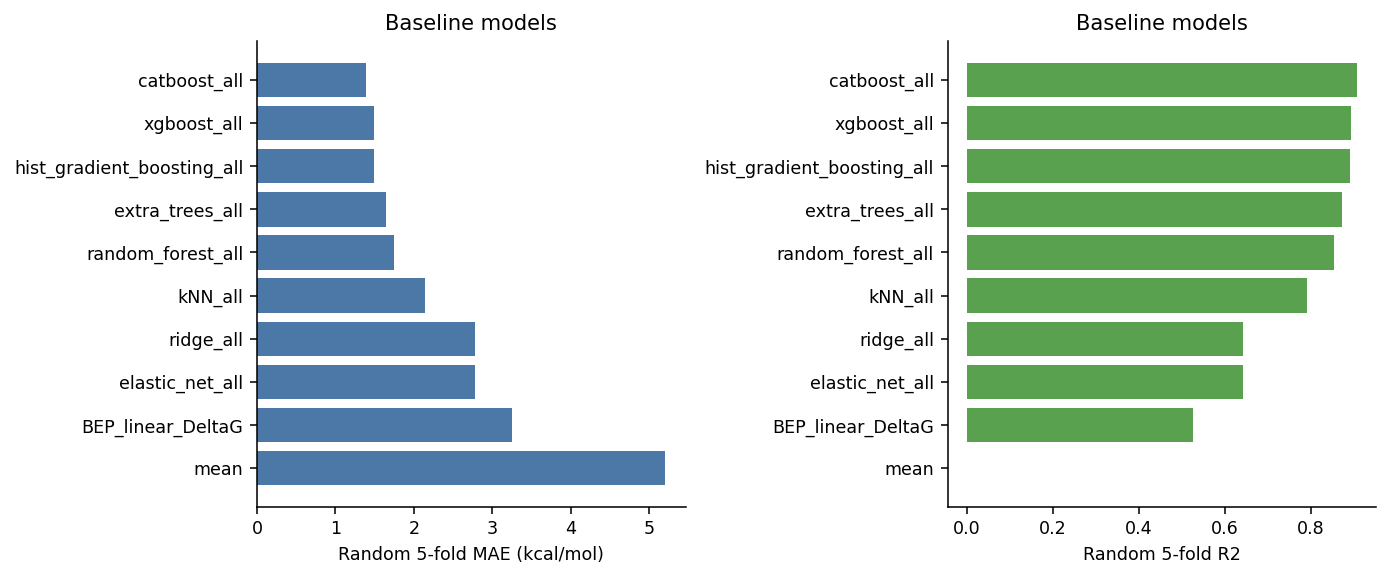

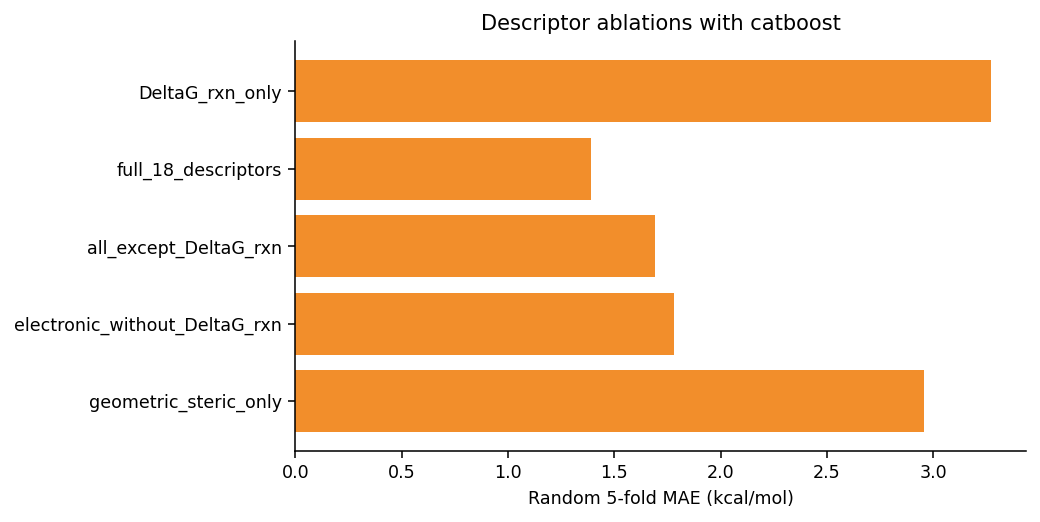

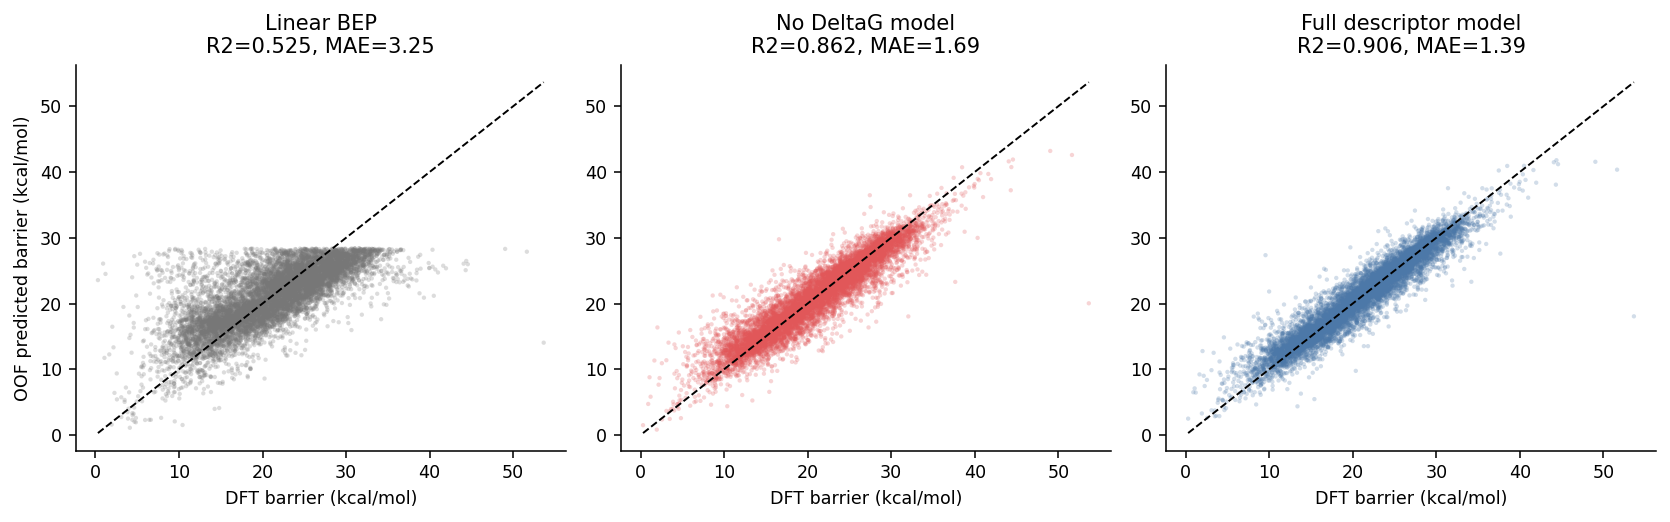

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
plot_df = baseline_cv.sort_values('MAE', ascending=True)
axes[0].barh(plot_df['model'], plot_df['MAE'], color='#4c78a8')
axes[0].set_xlabel('Random 5-fold MAE (kcal/mol)')
axes[0].invert_yaxis()
axes[0].set_title('Baseline models')
axes[1].barh(plot_df['model'], plot_df['R2'], color='#59a14f')
axes[1].set_xlabel('Random 5-fold R2')
axes[1].invert_yaxis()
axes[1].set_title('Baseline models')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'FigureS_model_baselines.png', bbox_inches='tight')
plt.show()

key_plot = ablation_cv.set_index('feature_set').loc[[s for s in key_ablation_sets if s in ablation_cv['feature_set'].values]].reset_index()
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.barh(key_plot['feature_set'], key_plot['MAE'], color='#f28e2b')
ax.set_xlabel('Random 5-fold MAE (kcal/mol)')
ax.invert_yaxis()
ax.set_title(f'Descriptor ablations with {ABLATION_MODEL_NAME}')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'FigureS_model_ablation.png', bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, name, preds, color in [
    (axes[0], 'Linear BEP', pred_bep_cv, '#777777'),
    (axes[1], 'No DeltaG model', ablation_predictions['all_except_DeltaG_rxn'], '#e15759'),
    (axes[2], 'Full descriptor model', ablation_predictions['full_18_descriptors'], '#4c78a8'),
]:
    ax.scatter(y, preds, s=5, alpha=0.25, color=color, edgecolors='none')
    lo = min(y.min(), preds.min())
    hi = max(y.max(), preds.max())
    ax.plot([lo, hi], [lo, hi], color='black', lw=1, ls='--')
    ax.set_title(f"{name}\nR2={r2_score(y, preds):.3f}, MAE={mean_absolute_error(y, preds):.2f}")
    ax.set_xlabel('DFT barrier (kcal/mol)')
axes[0].set_ylabel('OOF predicted barrier (kcal/mol)')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'FigureS_bep_dependence.png', bbox_inches='tight')
plt.show()

## Interpretation Notes For Response Drafting

Use the generated CSVs rather than hand-copying notebook output.

Suggested reviewer-response logic:
- Report the `BEP_linear_DeltaG` row as the formal BEP baseline.
- Compare it with `catboost_all` in the baseline table.
- Emphasize the CatBoost-first `all_except_DeltaG_rxn` ablation: if this model remains much better than mean and close to the full model, the descriptor model is not merely recapitulating BEP.
- Use `BEP_plus_residual_catboost` to state explicitly that non-`DeltaG_rxn` descriptors learn systematic BEP residuals.
- Use OOD rows with caution: leave-class-out MAE is the more realistic number for new Lewis-base/chloride classes and should be reported alongside random CV.
